<a href="https://colab.research.google.com/github/Bryan-ing/Master-s-Degree-in-AI/blob/main/Describir_Visualizar_Datos_AllenDowney.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea Clase 1: Describir y Visualizar Datos
## Maestría en Inteligencia Artificial

**Dataset:** BRFSS (Behavioral Risk Factor Surveillance System)

### Instrucciones
Completa los ejercicios marcados con **# TU CÓDIGO AQUÍ**. Cada ejercicio tiene pistas para ayudarte.

---
## 0. Configuración Inicial

In [45]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Librerías importadas")

Librerías importadas


---
## 1. Cargar el Dataset BRFSS

El **BRFSS** es una encuesta telefónica sobre salud realizada por los CDC. Contiene datos sobre:
- Peso y altura de los participantes
- Edad, sexo
- Hábitos de salud

In [46]:
# Descargar datos BRFSS
import os
from urllib.request import urlretrieve

# Permalink debe convertirse a RAW (https://github.com/AllenDowney/ThinkStats2/blob/ed53b15755e08fccfdac07af5e5aac76e4507731/homeworks/brfss.hdf5)
url = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/ed53b15755e08fccfdac07af5e5aac76e4507731/homeworks/brfss.hdf5"
#      ^^^^^^^^^^^^^^^^^^^^^^^^^^^              quitar el /blob/  ^^^"
filename = "brfss.hdf5"

if not os.path.exists(filename):
    print("Descargando datos BRFSS...")
    try:
        urlretrieve(url, filename)
        print("Datos descargados correctamente")
    except Exception as e:
        print(f"Error al descargar: {e}")
else:
    print("Datos ya existen")

# Cargar datos
brfss = pd.read_hdf(filename, 'brfss')
print(f"Dataset cargado: {brfss.shape[0]:,} filas x {brfss.shape[1]} columnas")

Datos ya existen
Dataset cargado: 100,000 filas x 9 columnas


### EJERCICIO 1: Exploración Inicial (10 puntos)

Muestra información básica del dataset.

In [47]:
# EJERCICIO 1.1: Muestra las primeras 5 filas del dataset
# PISTA: Usa el método .head()
# TU CÓDIGO AQUÍ
df = pd.read_hdf('brfss.hdf5')
print(df.head())

        SEX   HTM4   WTKG3  INCOME2       _LLCPWT  _AGEG5YR  _VEGESU1  \
96230   2.0  160.0   60.33      8.0   1398.525290       6.0      2.14   
244920  2.0  163.0   58.97      5.0     84.057503      13.0      3.14   
57312   2.0  163.0   72.57      8.0    390.248599       5.0      2.64   
32573   2.0  165.0   74.84      1.0  11566.705300       3.0      1.46   
355929  2.0  170.0  108.86      3.0    844.485450       3.0      1.81   

        _HTMG10   AGE  
96230     150.0  47.0  
244920    160.0  89.5  
57312     160.0  42.0  
32573     160.0  32.0  
355929    160.0  32.0  


In [48]:
# EJERCICIO 1.2: Muestra los nombres de las columnas
# PISTA: Usa brfss.columns
# TU CÓDIGO AQUÍ
columnas = brfss.columns
print("Columnas disponibles:")
print(columnas)

Columnas disponibles:
Index(['SEX', 'HTM4', 'WTKG3', 'INCOME2', '_LLCPWT', '_AGEG5YR', '_VEGESU1',
       '_HTMG10', 'AGE'],
      dtype='object')


In [49]:
# EJERCICIO 1.3: Calcula cuántos valores faltantes hay en cada columna
# PISTA: Usa .isnull().sum()
# TU CÓDIGO AQUÍ
valores_faltantes = brfss.isnull().sum()
print("\nValores faltantes por columna:")
print(valores_faltantes)


Valores faltantes por columna:
SEX            62
HTM4         4857
WTKG3        6596
INCOME2     16553
_LLCPWT         0
_AGEG5YR     1206
_VEGESU1    12287
_HTMG10      4857
AGE          1206
dtype: int64


---
## 2. Análisis de la Variable Peso (wtkg2)

La columna `wtkg2` contiene el peso en kilogramos.

### EJERCICIO 2: Estadísticas Descriptivas (15 puntos)

In [50]:
# EJERCICIO 2.1: Filtrar datos válidos de peso (entre 30 y 200 kg)
# PISTA: Usa condiciones con & (and) para filtrar
# TU CÓDIGO AQUÍ
pesos_validos = brfss[(brfss['WTKG3'] >= 30) & (brfss['WTKG3'] <= 200)]['WTKG3'].dropna()

print(f"Total de pesos válidos: {len(pesos_validos):,}")

Total de pesos válidos: 93,335


In [51]:
# EJERCICIO 2.2: Calcula las siguientes estadísticas del peso:
# - Media
# - Mediana
# - Desviación estándar
# - Mínimo y Máximo

# TU CÓDIGO AQUÍ
media_peso = pesos_validos.mean()
mediana_peso = pesos_validos.median()
std_peso = pesos_validos.std()
min_peso = pesos_validos.min()
max_peso = pesos_validos.max()

print("\nEstadísticas de Peso (kg):")
print(f"  Media: {media_peso:.2f}")
print(f"  Mediana: {mediana_peso:.2f}")
print(f"  Desv. Estándar: {std_peso:.2f}")
print(f"  Mínimo: {min_peso:.2f}")
print(f"  Máximo: {max_peso:.2f}")


Estadísticas de Peso (kg):
  Media: 81.12
  Mediana: 78.93
  Desv. Estándar: 20.61
  Mínimo: 31.30
  Máximo: 200.00


In [52]:
# EJERCICIO 2.3: Calcula los percentiles 25, 50, 75 y 90
# PISTA: Usa .quantile() con los valores apropiados

# TU CÓDIGO AQUÍ
p25 = pesos_validos.quantile(0.25)  # El 25% de la población pesa menos que este valor
p50 = pesos_validos.quantile(0.50)  # Es exactamente el mismo valor que la MEDIANA
p75 = pesos_validos.quantile(0.75)  # El 75% pesa menos que esto (o el 25% pesa más)
p90 = pesos_validos.quantile(0.90)  # El top 10% de peso más alto

print("\nPercentiles del Peso:")
print(f"  P25: {p25:.2f} kg")
print(f"  P50: {p50:.2f} kg")
print(f"  P75: {p75:.2f} kg")
print(f"  P90: {p90:.2f} kg")


Percentiles del Peso:
  P25: 66.22 kg
  P50: 78.93 kg
  P75: 90.72 kg
  P90: 108.86 kg


---
## 3. Visualización del Peso

### EJERCICIO 3: Crear Visualizaciones (20 puntos)

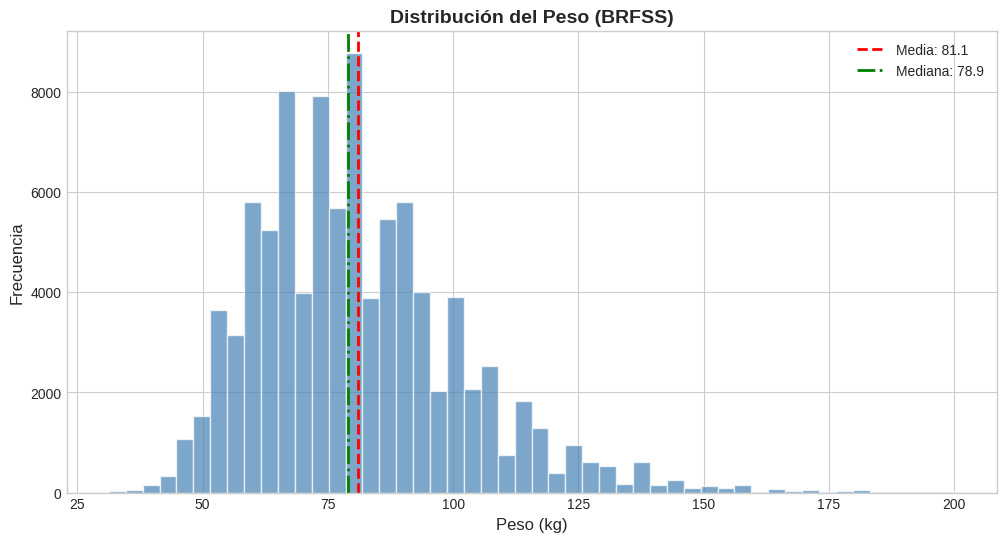

In [53]:
# EJERCICIO 3.1: Crea un histograma del peso
# Requisitos:
# - Usa 50 bins
# - Color: steelblue
# - Añade líneas verticales para media (rojo) y mediana (verde)

fig, ax = plt.subplots(figsize=(12, 6))

# TU CÓDIGO AQUÍ
# 1. Crea el histograma
ax.hist(pesos_validos, bins=50, color='steelblue', edgecolor='white', alpha=0.7)

# 2. Añade línea vertical para la media
ax.axvline(media_peso, color='red', linestyle='--', linewidth=2, label=f'Media: {media_peso:.1f}')

# 3. Añade línea vertical para la mediana
ax.axvline(mediana_peso, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {mediana_peso:.1f}')

ax.set_xlabel('Peso (kg)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución del Peso (BRFSS)', fontsize=14, fontweight='bold')
ax.legend()
plt.show()

/tmp/ipykernel_3466/1178121356.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(pesos_validos, labels=['Peso (kg)'], patch_artist=True)


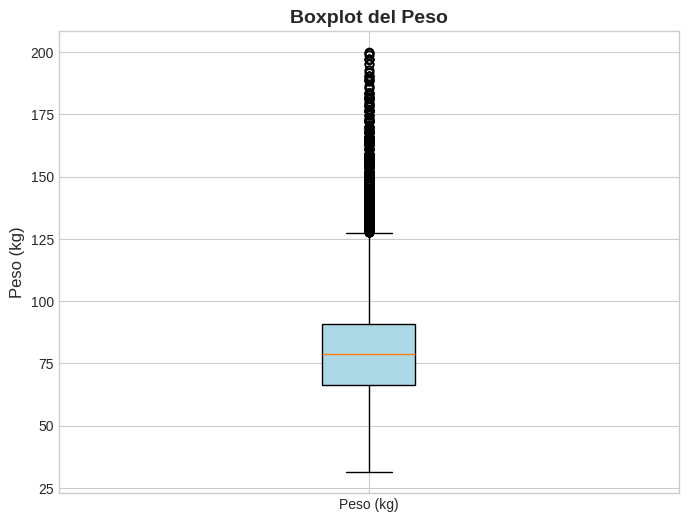

In [54]:
# EJERCICIO 3.2: Crea un boxplot del peso
# PISTA: Usa plt.boxplot() o ax.boxplot()

fig, ax = plt.subplots(figsize=(8, 6))

# TU CÓDIGO AQUÍ
bp = ax.boxplot(pesos_validos, labels=['Peso (kg)'], patch_artist=True)

# Personalizar color
bp['boxes'][0].set_facecolor('lightblue')

ax.set_ylabel('Peso (kg)', fontsize=12)
ax.set_title('Boxplot del Peso', fontsize=14, fontweight='bold')
plt.show()

---
## 4. Análisis de la Variable Altura (htm3)

### EJERCICIO 4: Análisis de Altura (15 puntos)

In [55]:
# EJERCICIO 4.1: Filtra alturas válidas (entre 100 y 250 cm)
# y calcula media, mediana y desviación estándar

# TU CÓDIGO AQUÍ
alturas_validas = brfss[(brfss['HTM4'] >= 100) & (brfss['HTM4'] <= 250)]['HTM4'].dropna()

media_altura = alturas_validas.mean()
mediana_altura = alturas_validas.median()
std_altura = alturas_validas.std()

print("Estadísticas de Altura (cm):")
print(f"  Media: {media_altura:.2f}")
print(f"  Mediana: {mediana_altura:.2f}")
print(f"  Desv. Estándar: {std_altura:.2f}")

Estadísticas de Altura (cm):
  Media: 170.09
  Mediana: 170.00
  Desv. Estándar: 10.78


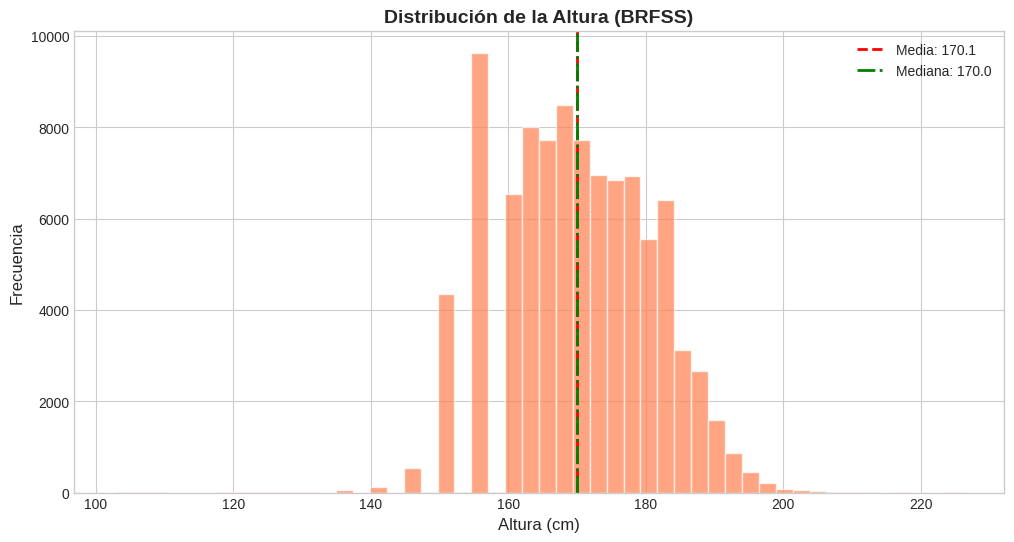

In [56]:
# EJERCICIO 4.2: Crea un histograma de la altura
# Añade líneas para media y mediana

fig, ax = plt.subplots(figsize=(12, 6))

# TU CÓDIGO AQUÍ
ax.hist(alturas_validas, bins=50, color='coral', edgecolor='white', alpha=0.7)
ax.axvline(media_altura, color='red', linestyle='--', linewidth=2, label=f'Media: {media_altura:.1f}')
ax.axvline(mediana_altura, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {mediana_altura:.1f}')

ax.set_xlabel('Altura (cm)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de la Altura (BRFSS)', fontsize=14, fontweight='bold')
ax.legend()
plt.show()

---
## 5. Comparación por Sexo

### EJERCICIO 5: Análisis Comparativo (20 puntos)

La columna `sex` tiene valores: 1=Hombre, 2=Mujer

In [57]:
# EJERCICIO 5.1: Separa los datos por sexo y calcula estadísticas de peso

# TU CÓDIGO AQUÍ
# Filtrar datos válidos primero
datos_validos = brfss[(brfss['WTKG3'] >= 30) & (brfss['WTKG3'] <= 200)].copy()

# Separar por sexo (1=Hombres, 2=Mujeres)
peso_hombres = datos_validos[datos_validos['SEX'] == 1]['WTKG3'].dropna()
peso_mujeres = datos_validos[datos_validos['SEX'] == 2]['WTKG3'].dropna()

# Impresión de resultados
print("Comparación de Peso por Sexo:")
print(f"\nHombres (n={len(peso_hombres):,}):")
print(f"  Media: {peso_hombres.mean():.2f} kg")
print(f"  Mediana: {peso_hombres.median():.2f} kg")
print(f"  Desv. Estándar: {peso_hombres.std():.2f} kg")

print(f"\nMujeres (n={len(peso_mujeres):,}):")
print(f"  Media: {peso_mujeres.mean():.2f} kg")
print(f"  Mediana: {peso_mujeres.median():.2f} kg")
print(f"  Desv. Estándar: {peso_mujeres.std():.2f} kg")

# 4. Cálculo de la diferencia
diferencia = peso_hombres.mean() - peso_mujeres.mean()
print(f"\nDiferencia en medias: {diferencia:.2f} kg")

Comparación de Peso por Sexo:

Hombres (n=46,433):
  Media: 88.73 kg
  Mediana: 86.18 kg
  Desv. Estándar: 19.70 kg

Mujeres (n=46,861):
  Media: 73.57 kg
  Mediana: 70.31 kg
  Desv. Estándar: 18.62 kg

Diferencia en medias: 15.15 kg


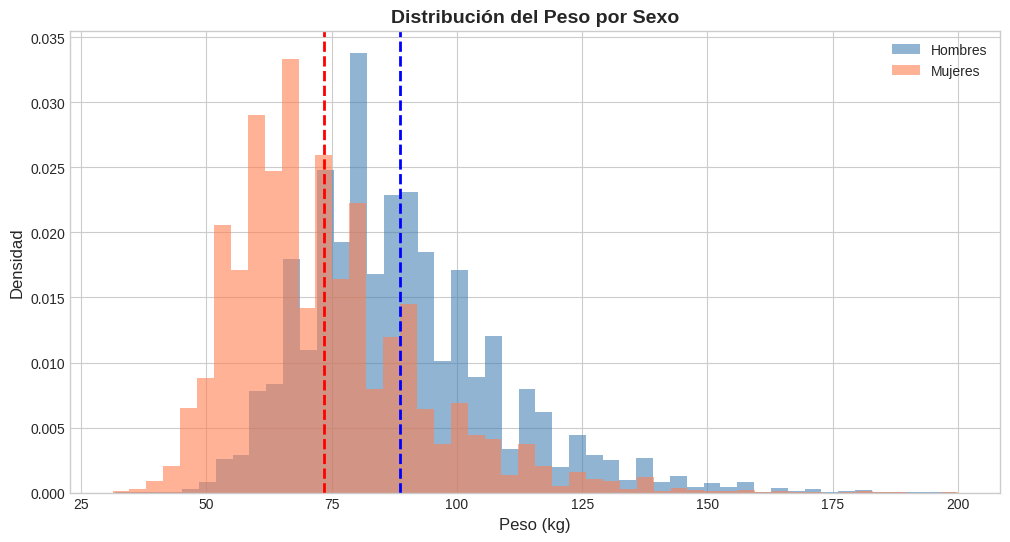

In [58]:
# EJERCICIO 5.2: Crea histogramas comparativos
# Muestra ambas distribuciones en el mismo gráfico

fig, ax = plt.subplots(figsize=(12, 6))

# TU CÓDIGO AQUÍ
ax.hist(peso_hombres, bins=50, alpha=0.6, label='Hombres', color='steelblue', density=True)
ax.hist(peso_mujeres, bins=50, alpha=0.6, label='Mujeres', color='coral', density=True)

ax.axvline(peso_hombres.mean(), color='blue', linestyle='--', linewidth=2)
ax.axvline(peso_mujeres.mean(), color='red', linestyle='--', linewidth=2)

ax.set_xlabel('Peso (kg)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Distribución del Peso por Sexo', fontsize=14, fontweight='bold')
ax.legend()
plt.show()

---
## 6. Correlación Peso-Altura

### EJERCICIO 6: Análisis de Correlación (20 puntos)

In [59]:
# EJERCICIO 6.1: Calcula la correlación entre peso y altura

# Primero, prepara los datos (sin valores faltantes)
corr_data = brfss[['WTKG3', 'HTM4']].dropna()
corr_data = corr_data[(corr_data['WTKG3'] >= 30) & (corr_data['WTKG3'] <= 200)]
corr_data = corr_data[(corr_data['HTM4'] >= 100) & (corr_data['HTM4'] <= 250)]

# TU CÓDIGO AQUÍ
correlacion = corr_data['WTKG3'].corr(corr_data['HTM4'])

print(f"Correlación Peso-Altura: {correlacion:.4f}")

# Interpretación
if correlacion > 0.5:
    print("Correlación FUERTE y positiva")
elif correlacion > 0.3:
    print("Correlación MODERADA y positiva")
elif correlacion > 0.1:
    print("Correlación DÉBIL y positiva")
else:
    print("Correlación muy débil o nula")

Correlación Peso-Altura: 0.4792
Correlación MODERADA y positiva


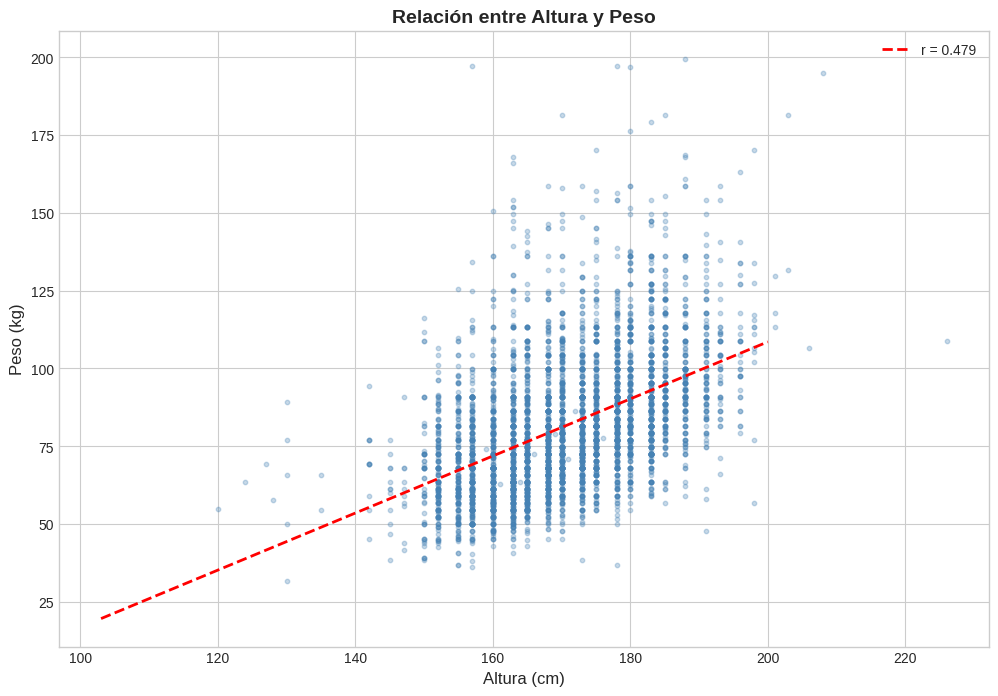

In [60]:
# EJERCICIO 6.2: Crea un scatter plot de Peso vs Altura O Grafico de disperción
# Añade una línea de tendencia

fig, ax = plt.subplots(figsize=(12, 8))

# Muestrear para mejor visualización
sample = corr_data.sample(n=min(5000, len(corr_data)), random_state=42) #graficamos solo una muestra de 5000 para que no se sature

# TU CÓDIGO AQUÍ
# 1. Scatter plot Usamos la muestra 'sample' para que no se trabe la compu con tantos puntos
ax.scatter(sample['HTM4'], sample['WTKG3'], alpha=0.3, s=10, color='steelblue') #EL alpha=0.3 Este parámetro es clave. Hace que los puntos sean semitransparentes.
# Donde veas el color más oscuro, significa que hay mucha densidad de personas con esa misma combinación de altura y peso
# 2. Línea de tendencia
z = np.polyfit(corr_data['HTM4'], corr_data['WTKG3'], 1) # el 1 indica que quiero una regresión de primer grado tipo linea recta
p = np.poly1d(z)
x_line = np.linspace(corr_data['HTM4'].min(), corr_data['WTKG3'].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, label=f'r = {correlacion:.3f}')

ax.set_xlabel('Altura (cm)', fontsize=12)
ax.set_ylabel('Peso (kg)', fontsize=12)
ax.set_title('Relación entre Altura y Peso', fontsize=14, fontweight='bold')
ax.legend()
plt.show()

---
## 7. Preguntas de Reflexión (10 puntos)

Responde las siguientes preguntas basándote en tu análisis:

**PREGUNTA 7.1:** ¿Por qué crees que la media del peso es mayor que la mediana? ¿Qué nos dice esto sobre la distribución?

**TU RESPUESTA:** _Analizando los graficos se refleja una afectación debido a que hay algunos valores que son los outliers que afectan a este punto especificamente en la parte de promedio, tal vez no es que sean mas personas sino que el valor de esas personas afecta a la media directamente elevandola._

**PREGUNTA 7.2:** ¿Qué diferencias observas en la distribución del peso entre hombres y mujeres? ¿Son estas diferencias las que esperabas?

**TU RESPUESTA:** _El grafico comparativo de estos refleja que en promedio es mas obeso el hombre, honestamente no esperaba este resultado de un analisis por el contrario creía que las mujeres en promedio padecian mayor indice de obesidad aunque cabe señalar que en algunos analisis el hombre solo presenta un IMC mas alto pero no refleja obesidad en ellos._

**PREGUNTA 7.3:** La correlación entre peso y altura es positiva pero no perfecta. ¿Qué otros factores crees que podrían influir en el peso de una persona además de su altura?
**TU RESPUESTA:** _Masa corporal, densidad osea, grasa acumulada, además de las cosas con las que fue medida la persona es decir tenis, ropa y cosas en las bolsas._

---
## Checklist de Entrega

Antes de entregar tu tarea, verifica:

- [ ] Todos los ejercicios de código están completos
- [ ] Las visualizaciones se muestran correctamente
- [ ] Las preguntas de reflexión están respondidas
- [ ] El notebook se ejecuta sin errores (Cell → Run All)

**Formato de entrega:** Sube el archivo `.ipynb` a la plataforma del curso.